# When weather crossed the line: rainfall, timing, and crop damage (2000–2024)

**And** — Farming depends on weather arriving at the *right time* and in the *right form*.

**But** — Annual rainfall *totals* can hide the events that actually damage crops:
hail, floods, drought, freezes, and damaging winds.

**Therefore** — This project looks beyond rainfall totals to identify **when** and
**where** weather crossed the line from normal climate to agricultural damage.

This notebook is the exploratory groundwork for that thesis. Each section is labeled
**AND / BUT / THEREFORE** so the analysis tracks the story, not just the columns.

## 0 · Setup & the data we actually have

State × year × crop panel: USDA yields joined to state-year precipitation and
state-year storm/crop-damage records (NOAA-style). Before any story, we need to
know the grain of the data and where it lies to us.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


def annotate_r(ax, x, y):
    """NaN-safe Pearson r drawn in an axes corner. Defined in setup so every
    figure cell can use it regardless of run order."""
    m = x.notna() & y.notna()
    r = np.corrcoef(x[m], y[m])[0, 1]
    ax.text(.05, .92, f"r = {r:+.3f}", transform=ax.transAxes,
            fontsize=15, fontweight="bold",
            bbox=dict(boxstyle="round", fc="white", ec="0.6"))


# CSV sits next to this notebook (fall back to ../data/ if a repo layout is used)
CSV = "crop_rain_state_2000_2024.csv"
if not Path(CSV).exists() and Path("../data/" + CSV).exists():
    CSV = "../data/" + CSV
raw = pd.read_csv(CSV)
print("raw shape:", raw.shape)
raw.head()

raw shape: (5767, 19)


,year,period,geo_level,state,state_ansi,crop,data_item,domain,domain_category,yield_bu_per_acre,STATE_FIPS,state_abbr,annual_precip_in,growing_season_precip_in,non_growing_season_precip_in,growing_season_share,growing_season_precip_state_percentile,crop_damage_event_count,crop_damage_usd
0,2024,YEAR,STATE,ALABAMA,1.000,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,112.000,1.000,AL,56.407,28.465,27.942,0.505,60.000,0.000,0.000
1,2024,YEAR,STATE,ARIZONA,4.000,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,225.000,4.000,AZ,33.074,3.027,30.047,0.092,28.000,0.000,0.000
2,2024,YEAR,STATE,ARKANSAS,5.000,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,187.000,5.000,AR,20.227,10.739,9.488,0.531,52.000,1.000,"1,000.000"
3,2024,YEAR,STATE,CALIFORNIA,6.000,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,182.000,6.000,CA,52.014,25.927,26.086,0.498,56.000,1.000,10.000
4,2024,YEAR,STATE,COLORADO,8.000,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,116.000,8.000,CO,57.153,38.434,18.719,0.672,68.000,18.000,"29,222,000.000"


In [22]:
# The 'period' column secretly mixes the FINAL official yield with 4 in-season
# forecast vintages -> the same (year, state, crop) appears up to 5 times.
print(raw["period"].value_counts(), "\n")
print("duplicate (year,state,crop) rows in raw:",
      raw.duplicated(subset=["year", "state", "crop"]).sum())
print("\nconstant columns:",
      [c for c in raw.columns if raw[c].nunique(dropna=False) == 1])

period
YEAR                   2821
YEAR - AUG FORECAST     744
YEAR - NOV FORECAST     744
YEAR - SEP FORECAST     744
YEAR - OCT FORECAST     714
Name: count, dtype: int64 

duplicate (year,state,crop) rows in raw: 2931

constant columns: ['geo_level', 'domain', 'domain_category']


**Cleaning decisions** (each one defended, not silent):

1. **Keep `period == "YEAR"`** — the final realized yield. The Aug/Sep/Oct/Nov
   "FORECAST" rows are in-season *predictions*; keeping them would duplicate every
   observation and leak forecasts into a historical analysis.
2. **Drop `state == "OTHER STATES"`** — an aggregation bucket with `yield = 0`
   and no weather/damage; not a real geography.
3. **Drop constant columns** (`geo_level`, `domain`, `domain_category`, …).
4. **Treat `annual_precip_in == 0` as missing** — zero inches of annual rainfall
   is physically impossible for these states. It marks state-years where the
   weather join failed (mostly recent years). Leaving it as 0 would fabricate a
   fake "dry" cluster and corrupt every precipitation relationship.
5. Build two frames: **`df`** (crop-level, for yield) and **`sy`** (one row per
   state-year, for the weather↔damage story — those fields are state-year, not
   per-crop).

In [23]:
df = raw[raw["period"] == "YEAR"].copy()
df = df[df["state"] != "OTHER STATES"].copy()

drop_cols = ["period", "geo_level", "domain", "domain_category",
             "data_item", "state_ansi", "STATE_FIPS"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

precip_cols = ["annual_precip_in", "growing_season_precip_in",
               "non_growing_season_precip_in"]
zero_mask = (df["annual_precip_in"] == 0)
print(f"state-years with precip recorded as 0 (-> set to NaN): "
      f"{df.loc[zero_mask, ['year','state']].drop_duplicates().shape[0]}")
df.loc[zero_mask, precip_cols + ["growing_season_share",
       "growing_season_precip_state_percentile"]] = np.nan

print("clean df shape:", df.shape,
      "| dup (year,state,crop):", df.duplicated(['year','state','crop']).sum())
print("yield min after cleaning:", df["yield_bu_per_acre"].min(),
      "| crops:", df["crop"].unique())

# One row per state-year: weather + damage are identical across crops, so this
# is the honest grain for any rainfall<->damage comparison.
sy = (df.dropna(subset=["annual_precip_in"])
        .drop_duplicates(subset=["year", "state"])
        .reset_index(drop=True))
print("\nstate-year frame `sy`:", sy.shape,
      "| states:", sy["state"].nunique(), "| years:", sy["year"].nunique())

state-years with precip recorded as 0 (-> set to NaN): 125
clean df shape: (2807, 12) | dup (year,state,crop): 0
yield min after cleaning: 11.0 | crops: ['CORN' 'WHEAT' 'SOYBEANS']

state-year frame `sy`: (919, 12) | states: 37 | years: 25


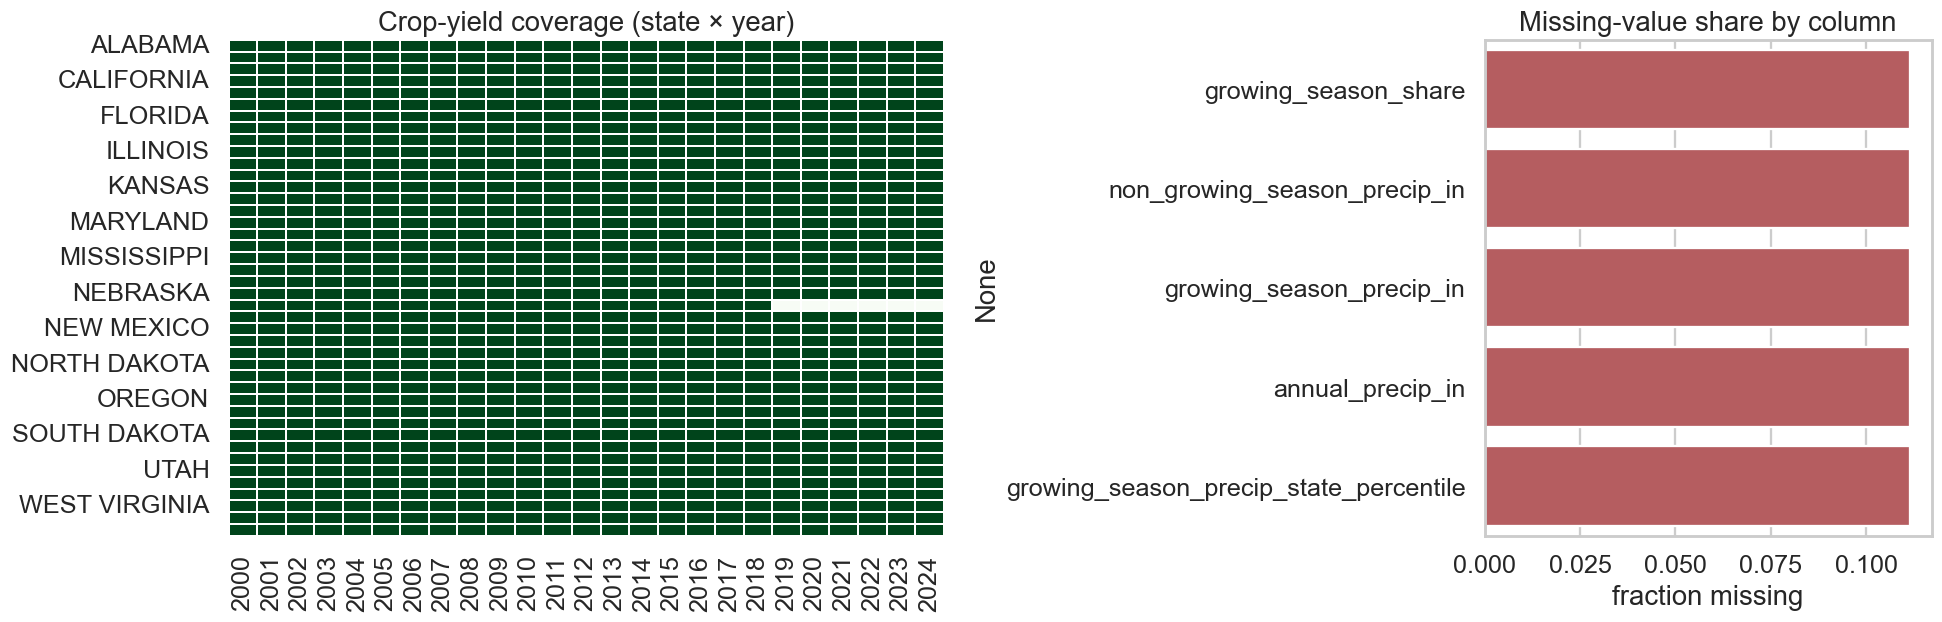

rows per crop:
 crop
CORN        1025
WHEAT       1019
SOYBEANS     763
Name: count, dtype: int64


In [24]:
# Coverage & missingness — what can each part of the story actually rest on?
fig, ax = plt.subplots(1, 2, figsize=(18, 6),
                       gridspec_kw={"width_ratios": [1.6, 1]})

cover = (df.pivot_table(index="state", columns="year",
                        values="yield_bu_per_acre", aggfunc="size")
           .notna().astype(int))
sns.heatmap(cover, cmap="Greens", cbar=False, ax=ax[0], linewidths=.2,
            linecolor="white")
ax[0].set_title("Crop-yield coverage (state × year)")
ax[0].set_xlabel(""); ax[0].set_ylabel("")

miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
sns.barplot(x=miss.values, y=miss.index, ax=ax[1], color="#c44e52")
ax[1].set_title("Missing-value share by column")
ax[1].set_xlabel("fraction missing")
plt.tight_layout(); plt.show()

print("rows per crop:\n", df["crop"].value_counts())

## 1 · AND — farming depends on weather arriving at the right *time* and *form*

Before arguing that totals hide things, establish the two facts the story stands
on: (a) yields are crop-specific and rise over time for reasons that have nothing
to do with weather (technology), and (b) the *timing* of rain — how much falls
*in the growing season* vs. outside it — varies enormously even at equal totals.

C:\Users\chenr\AppData\Local\Temp\ipykernel_17536\582886224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="crop", y="yield_bu_per_acre",


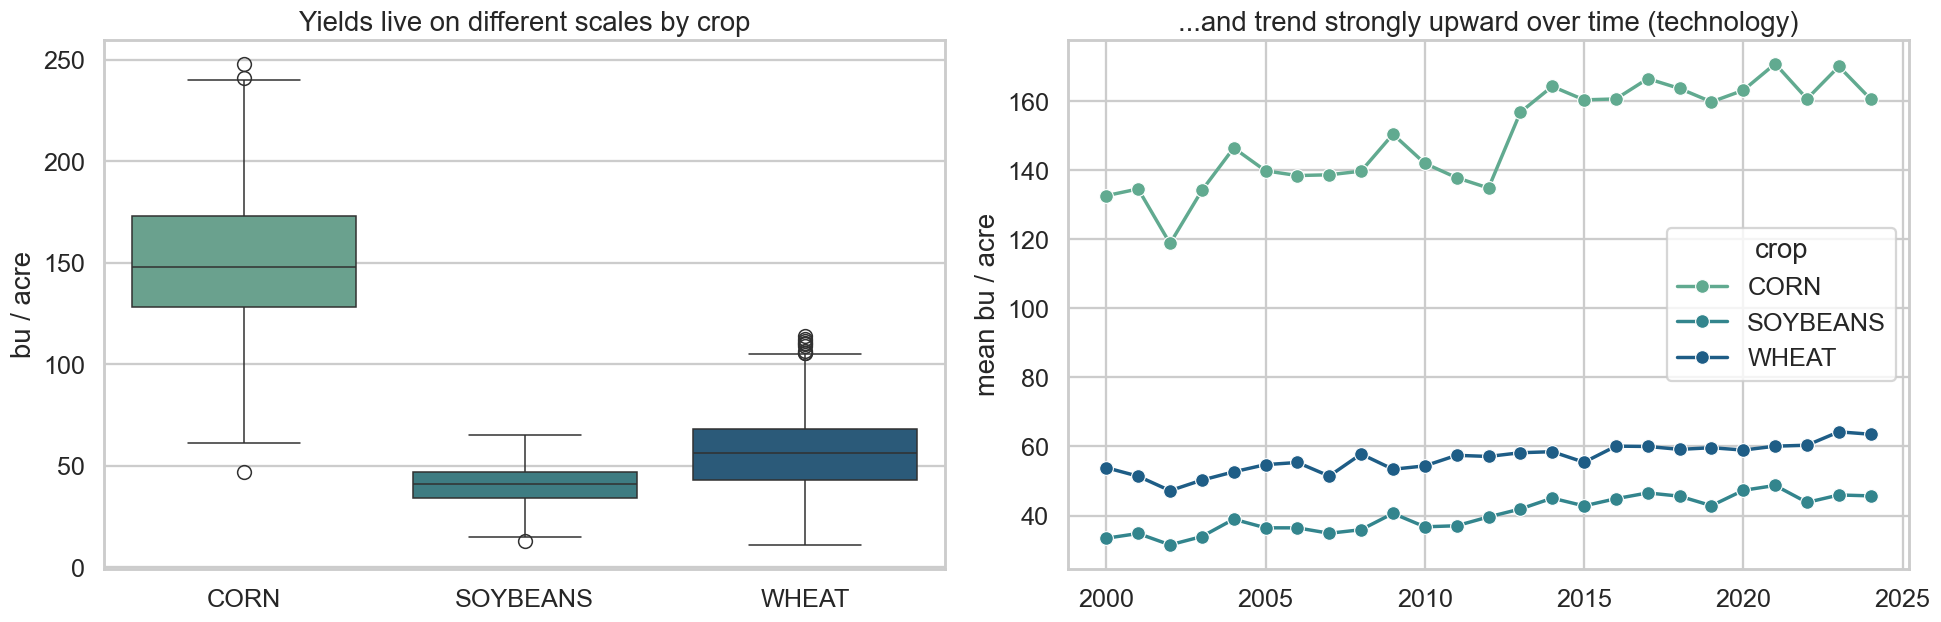

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df, x="crop", y="yield_bu_per_acre",
            order=["CORN", "SOYBEANS", "WHEAT"], ax=ax[0],
            palette="crest")
ax[0].set_title("Yields live on different scales by crop")
ax[0].set_xlabel(""); ax[0].set_ylabel("bu / acre")

trend = df.groupby(["year", "crop"])["yield_bu_per_acre"].mean().reset_index()
sns.lineplot(data=trend, x="year", y="yield_bu_per_acre", hue="crop",
             marker="o", ax=ax[1], palette="crest")
ax[1].set_title("...and trend strongly upward over time (technology)")
ax[1].set_xlabel(""); ax[1].set_ylabel("mean bu / acre")
plt.tight_layout(); plt.show()

That upward march is **not** weather — it is seed genetics, equipment, and
practice. So later, when we ask "does weather move yield?", we must compare
against a *detrended* yield, otherwise the technology trend drowns the signal.

# TAKEAWAY1: annual precipitation对于农作物的产量影响不稳定（因为growing season precipitation和annual precipitation不成正比）

### 图一
### 所有 state-year records的growing season share的分布情况
### 0.8那个column的含义是，在所有 state-year records里，有20个observation的80%降雨量都在growing season期间
### 在所有 state-year records 里，有一半的记录 growing_season_share 小于 0.56，另一半大于 0.56

### 图二
### 看annual precipitation around 40的
### annual precipitation一样/相近，但是growing season share大不相同

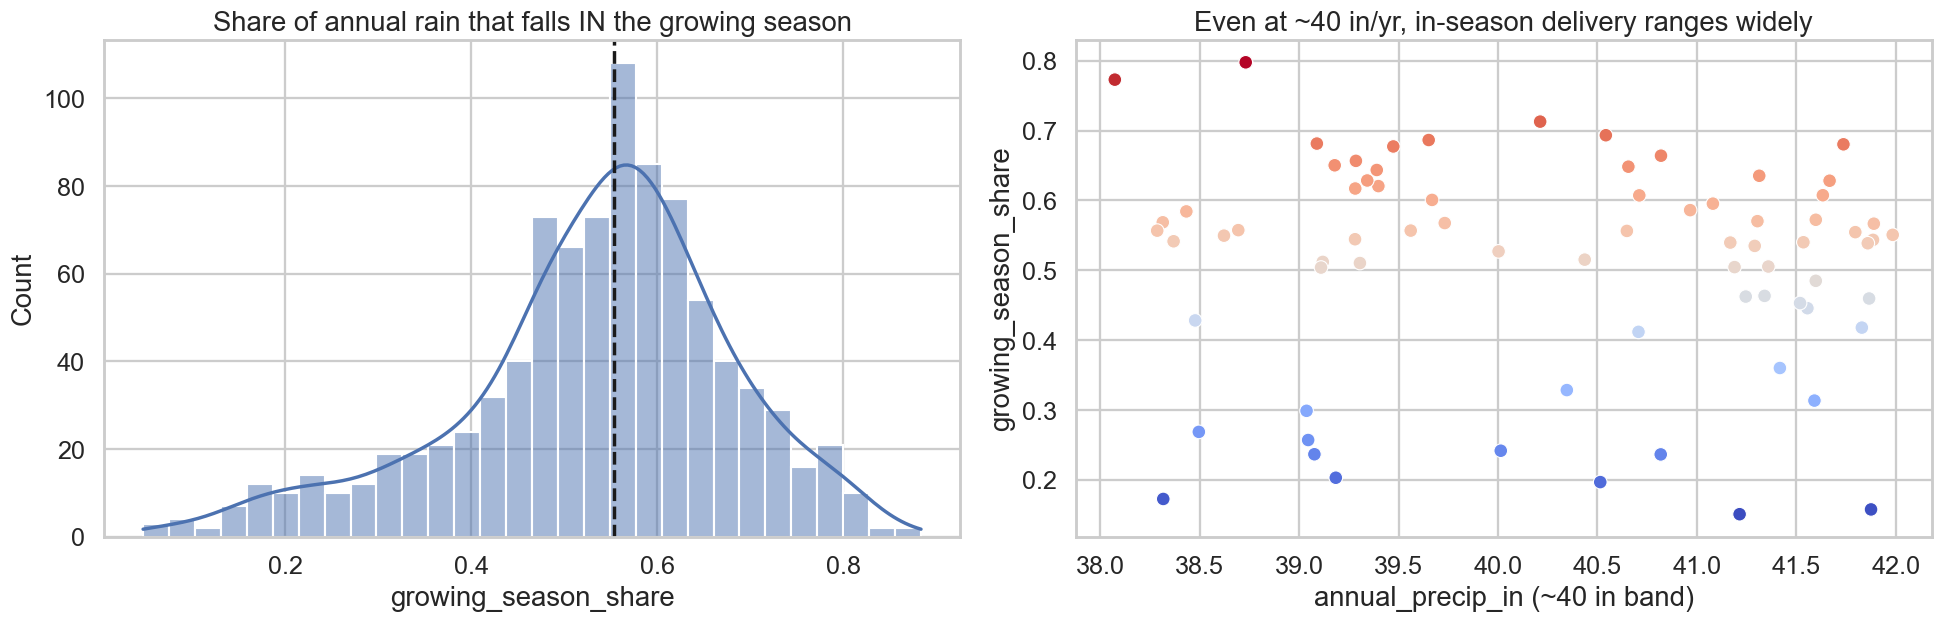

At ~40 in/yr total, growing-season share spans 0.15 to 0.80 -- the same annual total, very different timing.


In [26]:
# The "form" of rain: annual = growing-season + non-growing-season.
# Same annual total can hide very different in-season delivery.
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(sy["growing_season_share"].dropna(), bins=30, kde=True,
             color="#4c72b0", ax=ax[0])
ax[0].axvline(sy["growing_season_share"].median(), color="k", ls="--")
ax[0].set_title("Share of annual rain that falls IN the growing season")
ax[0].set_xlabel("growing_season_share")

band = sy[(sy["annual_precip_in"] > 38) & (sy["annual_precip_in"] < 42)]
sns.scatterplot(data=band, x="annual_precip_in", y="growing_season_share",
                hue="growing_season_share", palette="coolwarm",
                legend=False, s=80, ax=ax[1])
ax[1].set_title("Even at ~40 in/yr, in-season delivery ranges widely")
ax[1].set_xlabel("annual_precip_in (~40 in band)")
ax[1].set_ylabel("growing_season_share")
plt.tight_layout(); plt.show()

print(f"At ~40 in/yr total, growing-season share spans "
      f"{band['growing_season_share'].min():.2f} to "
      f"{band['growing_season_share'].max():.2f} "
      f"-- the same annual total, very different timing.")

## 2 · BUT — annual totals hide the events that damage crops

Now the turn. If a single annual rainfall number captured what matters, it would
correlate with yield and with damage. It does **neither**.

# TAKEAWAY2 （annual precipitation 对 yield 的解释力很弱）

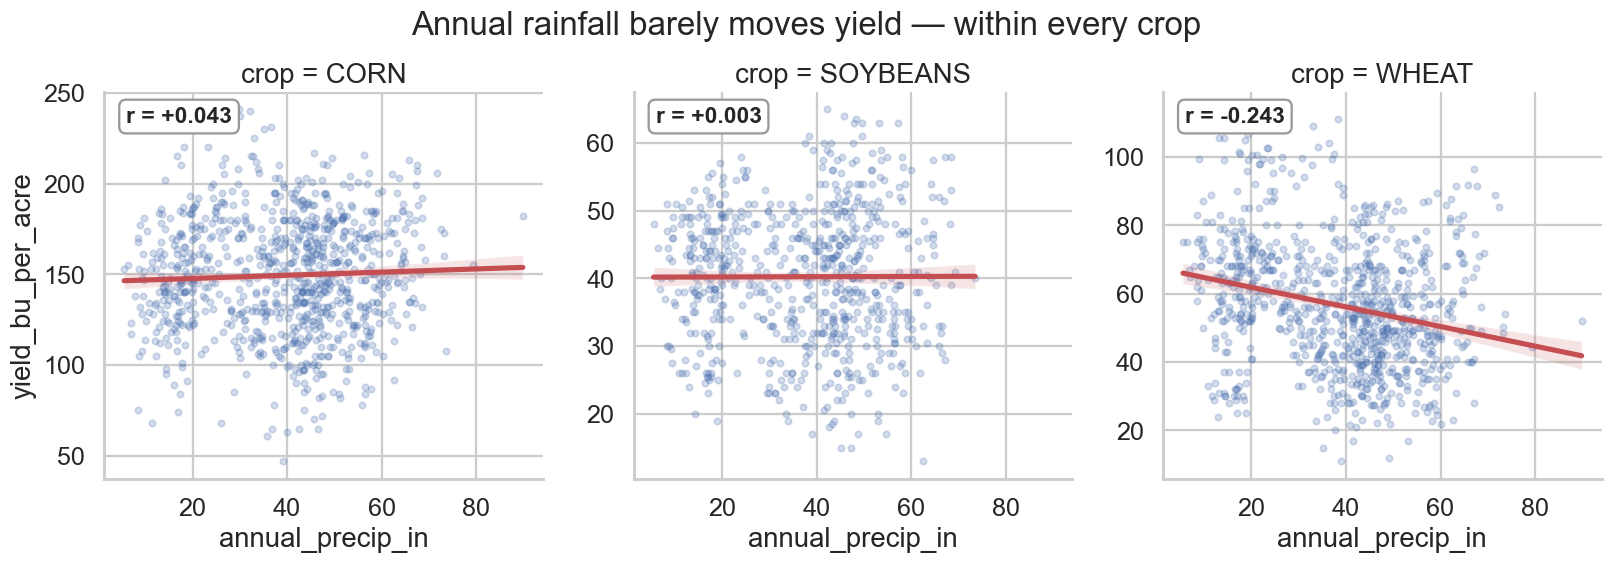

In [27]:
# annotate_r is defined in the setup cell (§0) -- run that cell first.
g = sns.lmplot(data=df, x="annual_precip_in", y="yield_bu_per_acre",
               col="crop", col_order=["CORN", "SOYBEANS", "WHEAT"],
               height=5, facet_kws=dict(sharey=False),
               scatter_kws=dict(alpha=.25, s=18),
               line_kws=dict(color="#c44e52"))
for crop, ax in zip(["CORN", "SOYBEANS", "WHEAT"], g.axes.flat):
    d = df[df["crop"] == crop]
    annotate_r(ax, d["annual_precip_in"], d["yield_bu_per_acre"])
g.figure.suptitle("Annual rainfall barely moves yield — within every crop",
                   y=1.04)
plt.show()

annual precipitation 和 yield 的关系，在每一种 crop 内部是否明显。

annual precipitation 对 yield 的解释力很弱

所以后面转向 growing-season precipitation / rainfall timing，而不是只看全年降水。

## TAKEAWAY3 （annual precipitation 对 damage 的解释力很弱）

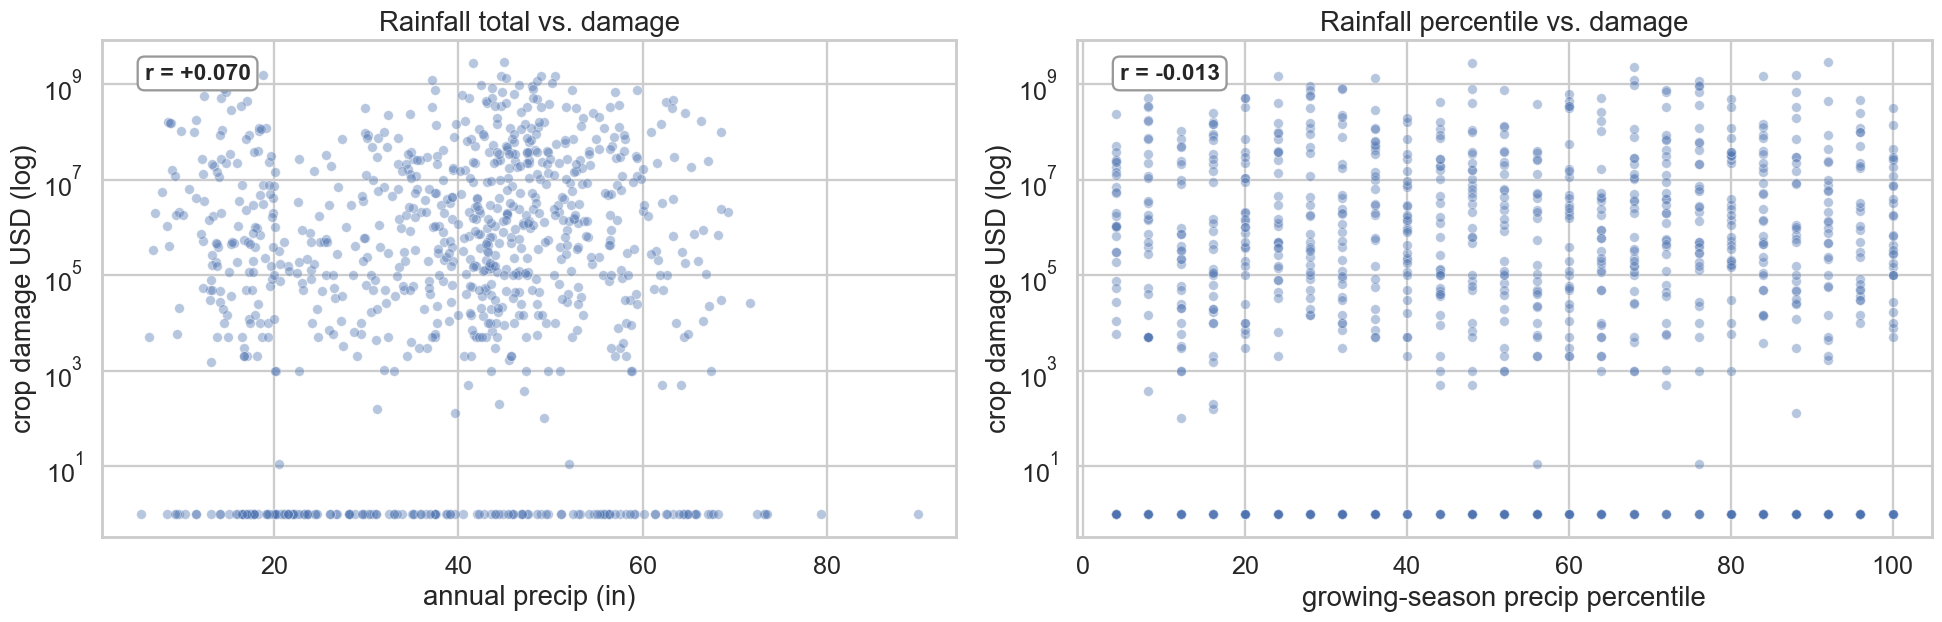

state-year correlations with crop_damage_usd:
  annual_precip_in            r = 0.0
  growing_season_percentile   r = -0.008


In [28]:
# Same test against DAMAGE, at the honest state-year grain.
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

for a, xcol, lab in [(ax[0], "annual_precip_in", "annual precip (in)"),
                     (ax[1], "growing_season_precip_state_percentile",
                      "growing-season precip percentile")]:
    sns.scatterplot(data=sy, x=xcol, y=sy["crop_damage_usd"] + 1,
                    alpha=.4, s=40, ax=a, color="#4c72b0")
    a.set_yscale("log")
    a.set_xlabel(lab); a.set_ylabel("crop damage USD (log)")
    annotate_r(a, sy[xcol], np.log10(sy["crop_damage_usd"] + 1))
ax[0].set_title("Rainfall total vs. damage")
ax[1].set_title("Rainfall percentile vs. damage")
plt.tight_layout(); plt.show()

print("state-year correlations with crop_damage_usd:")
print("  annual_precip_in            r =",
      round(sy["annual_precip_in"].corr(sy["crop_damage_usd"]), 3))
print("  growing_season_percentile   r =",
      round(sy["growing_season_precip_state_percentile"]
            .corr(sy["crop_damage_usd"]), 3))

单独用降水量或者降水 percentile 很难解释 crop damage；crop damage 更可能集中在具体的 extreme events / state-year disasters，而不是被 annual rainfall 平滑预测。

**Both relationships are ~0.** A year's rainfall total — even its *percentile*,
the climatologist's "was this a wet/dry year?" — tells you almost nothing about
whether crops were damaged. So where does damage live? In a few extreme events.

In [31]:
df["crop_damage_usd"].describe()

count           2,807.000
mean       59,292,737.773
std       239,976,080.229
min                 0.000
25%             5,570.000
50%           350,000.000
75%        10,938,000.000
max     2,888,001,400.000
Name: crop_damage_usd, dtype: float64

In [36]:
damage_obs = (
    df[df["crop_damage_usd"] > 0]
    .groupby(["state", "year"], as_index=False)
    .agg(
        observation_count=("crop_damage_usd", "size"),
        total_damage_usd=("crop_damage_usd", "sum"),
        avg_damage_usd=("crop_damage_usd", "mean"),
        crops=("crop", lambda x: ", ".join(sorted(x.unique())))
    )
    .sort_values("total_damage_usd", ascending=False)
)

damage_obs.shape[0] / df.shape[0]

0.2988956180976131

## TAKEAWAY4 damage distribution

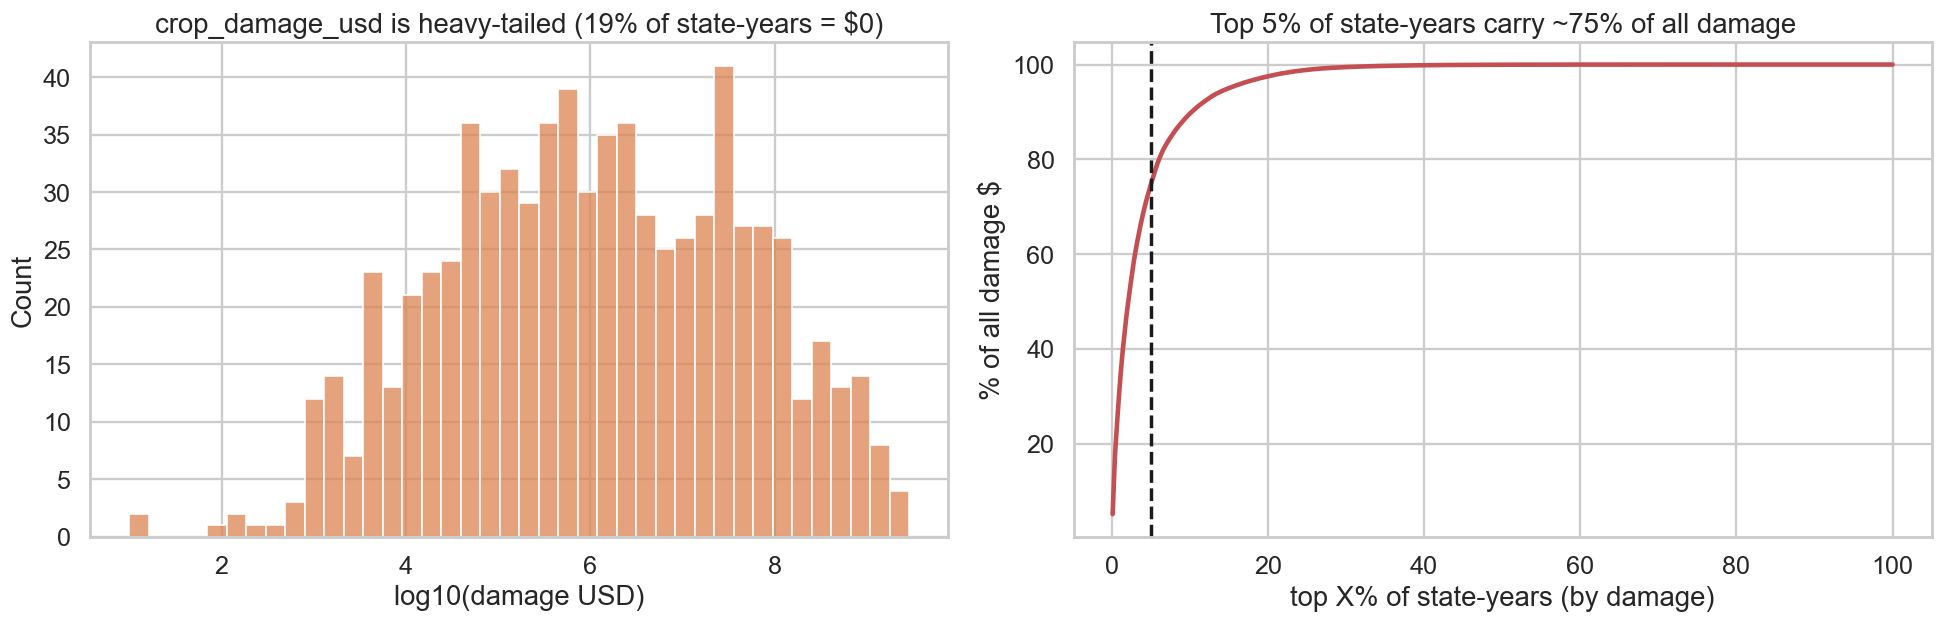

In [29]:
# Damage is rare and brutally concentrated.
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

pos = sy[sy["crop_damage_usd"] > 0]["crop_damage_usd"]
sns.histplot(np.log10(pos), bins=40, color="#dd8452", ax=ax[0])
ax[0].set_title(f"crop_damage_usd is heavy-tailed "
                f"({(sy['crop_damage_usd']==0).mean():.0%} of state-years = $0)")
ax[0].set_xlabel("log10(damage USD)")

s = np.sort(sy["crop_damage_usd"].values)[::-1]
cum = np.cumsum(s) / s.sum()
ax[1].plot(np.arange(1, len(s) + 1) / len(s) * 100, cum * 100, lw=3,
           color="#c44e52")
ax[1].set_xlabel("top X% of state-years (by damage)")
ax[1].set_ylabel("% of all damage $")
top5 = cum[int(.05 * len(s))] * 100
ax[1].axvline(5, color="k", ls="--")
ax[1].set_title(f"Top 5% of state-years carry ~{top5:.0f}% of all damage")
plt.tight_layout(); plt.show()

log10 = 4  →  $10,000

log10 = 5  →  $100,000

log10 = 6  →  $1,000,000

log10 = 7  →  $10,000,000

log10 = 8  →  $100,000,000

### crop damage is driven by a small number of severe state-year disasters rather than being evenly spread across all years and states.

#### 图一：crop_damage_usd 的分布情况
#### state-year records的分布情况（损失差距很大）

#### 图二：
#### 只占全部 observation 5% 的最高损失 state-year，贡献了大约 75% 的总 crop damage。crop damage 不是平均分布的，而是非常集中在少数 state-year disasters 里面。

## 3 · THEREFORE — find *when* and *where* weather crossed the line

If totals are blind to damage, then the project must localize damage in **space**
and **time**, and show it does not line up with rainfall extremes.

## TAKEAWAY5 Damge distribution

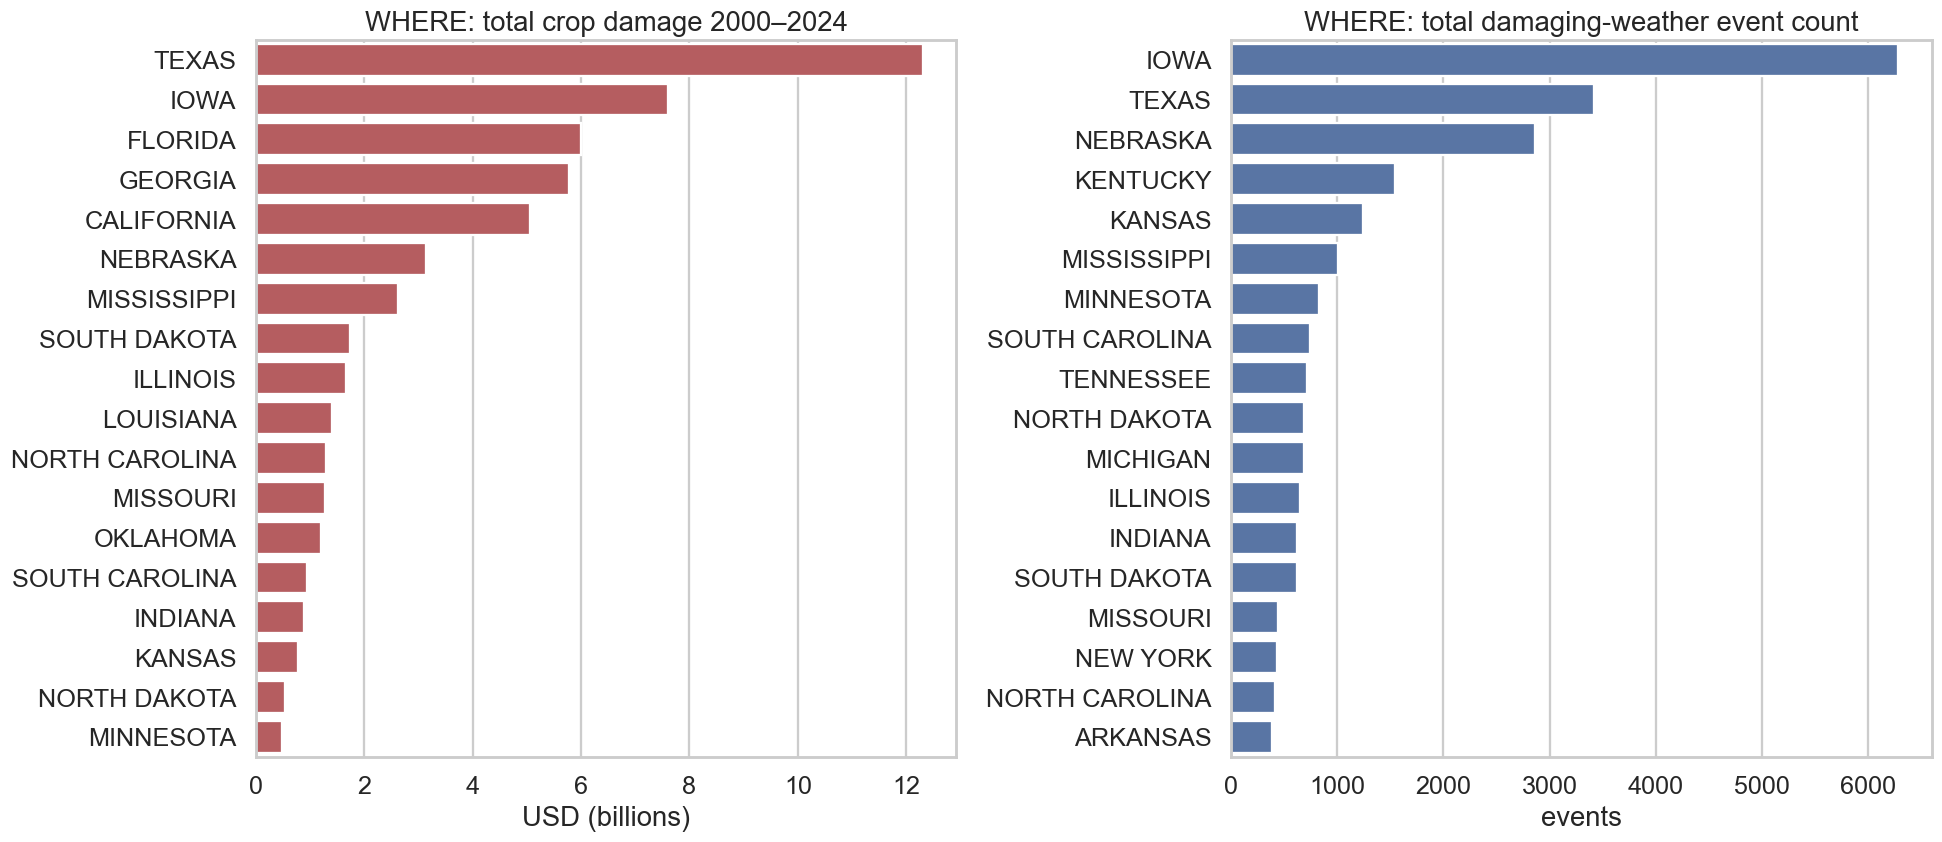

In [10]:
# WHERE
agg = (sy.groupby("state")
         .agg(total_usd=("crop_damage_usd", "sum"),
              events=("crop_damage_event_count", "sum"))
         .sort_values("total_usd", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
top = agg.head(18)
sns.barplot(x=top["total_usd"] / 1e9, y=top.index, ax=ax[0], color="#c44e52")
ax[0].set_title("WHERE: total crop damage 2000–2024")
ax[0].set_xlabel("USD (billions)"); ax[0].set_ylabel("")

te = agg.sort_values("events", ascending=False).head(18)
sns.barplot(x=te["events"], y=te.index, ax=ax[1], color="#4c72b0")
ax[1].set_title("WHERE: total damaging-weather event count")
ax[1].set_xlabel("events"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

左图看“哪里损失金额最大”，右图看“哪里灾害事件最多”；两者不完全一致，说明 crop damage 不只是事件数量问题，还和每次事件的严重程度有关。

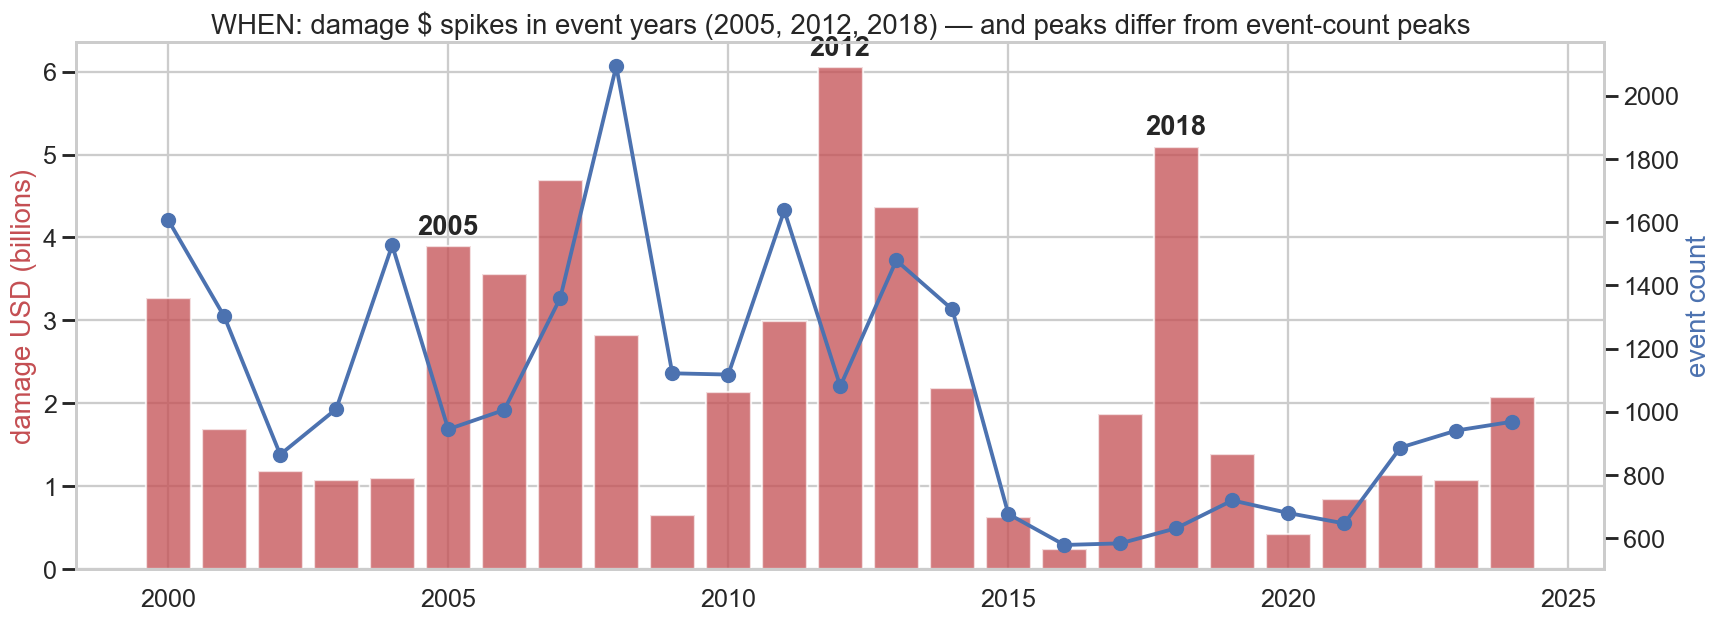

In [11]:
# WHEN
yr = sy.groupby("year").agg(usd=("crop_damage_usd", "sum"),
                            events=("crop_damage_event_count", "sum"))
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.bar(yr.index, yr["usd"] / 1e9, color="#c44e52", alpha=.75,
        label="damage $B")
ax1.set_ylabel("damage USD (billions)", color="#c44e52")
ax2 = ax1.twinx()
ax2.plot(yr.index, yr["events"], color="#4c72b0", marker="o", lw=2.5,
         label="event count")
ax2.set_ylabel("event count", color="#4c72b0"); ax2.grid(False)
for y in [2005, 2012, 2018]:
    ax1.annotate(str(y), (y, yr.loc[y, "usd"] / 1e9),
                 textcoords="offset points", xytext=(0, 8), ha="center",
                 fontweight="bold")
ax1.set_title("WHEN: damage $ spikes in event years (2005, 2012, 2018) — "
              "and peaks differ from event-count peaks")
plt.tight_layout(); plt.show()

crop damage 在少数年份突然暴涨，而且 damage 金额高峰和事件数量高峰不完全一致，所以真正重要的不只是“发生了多少事件”，还有“事件有多严重”。

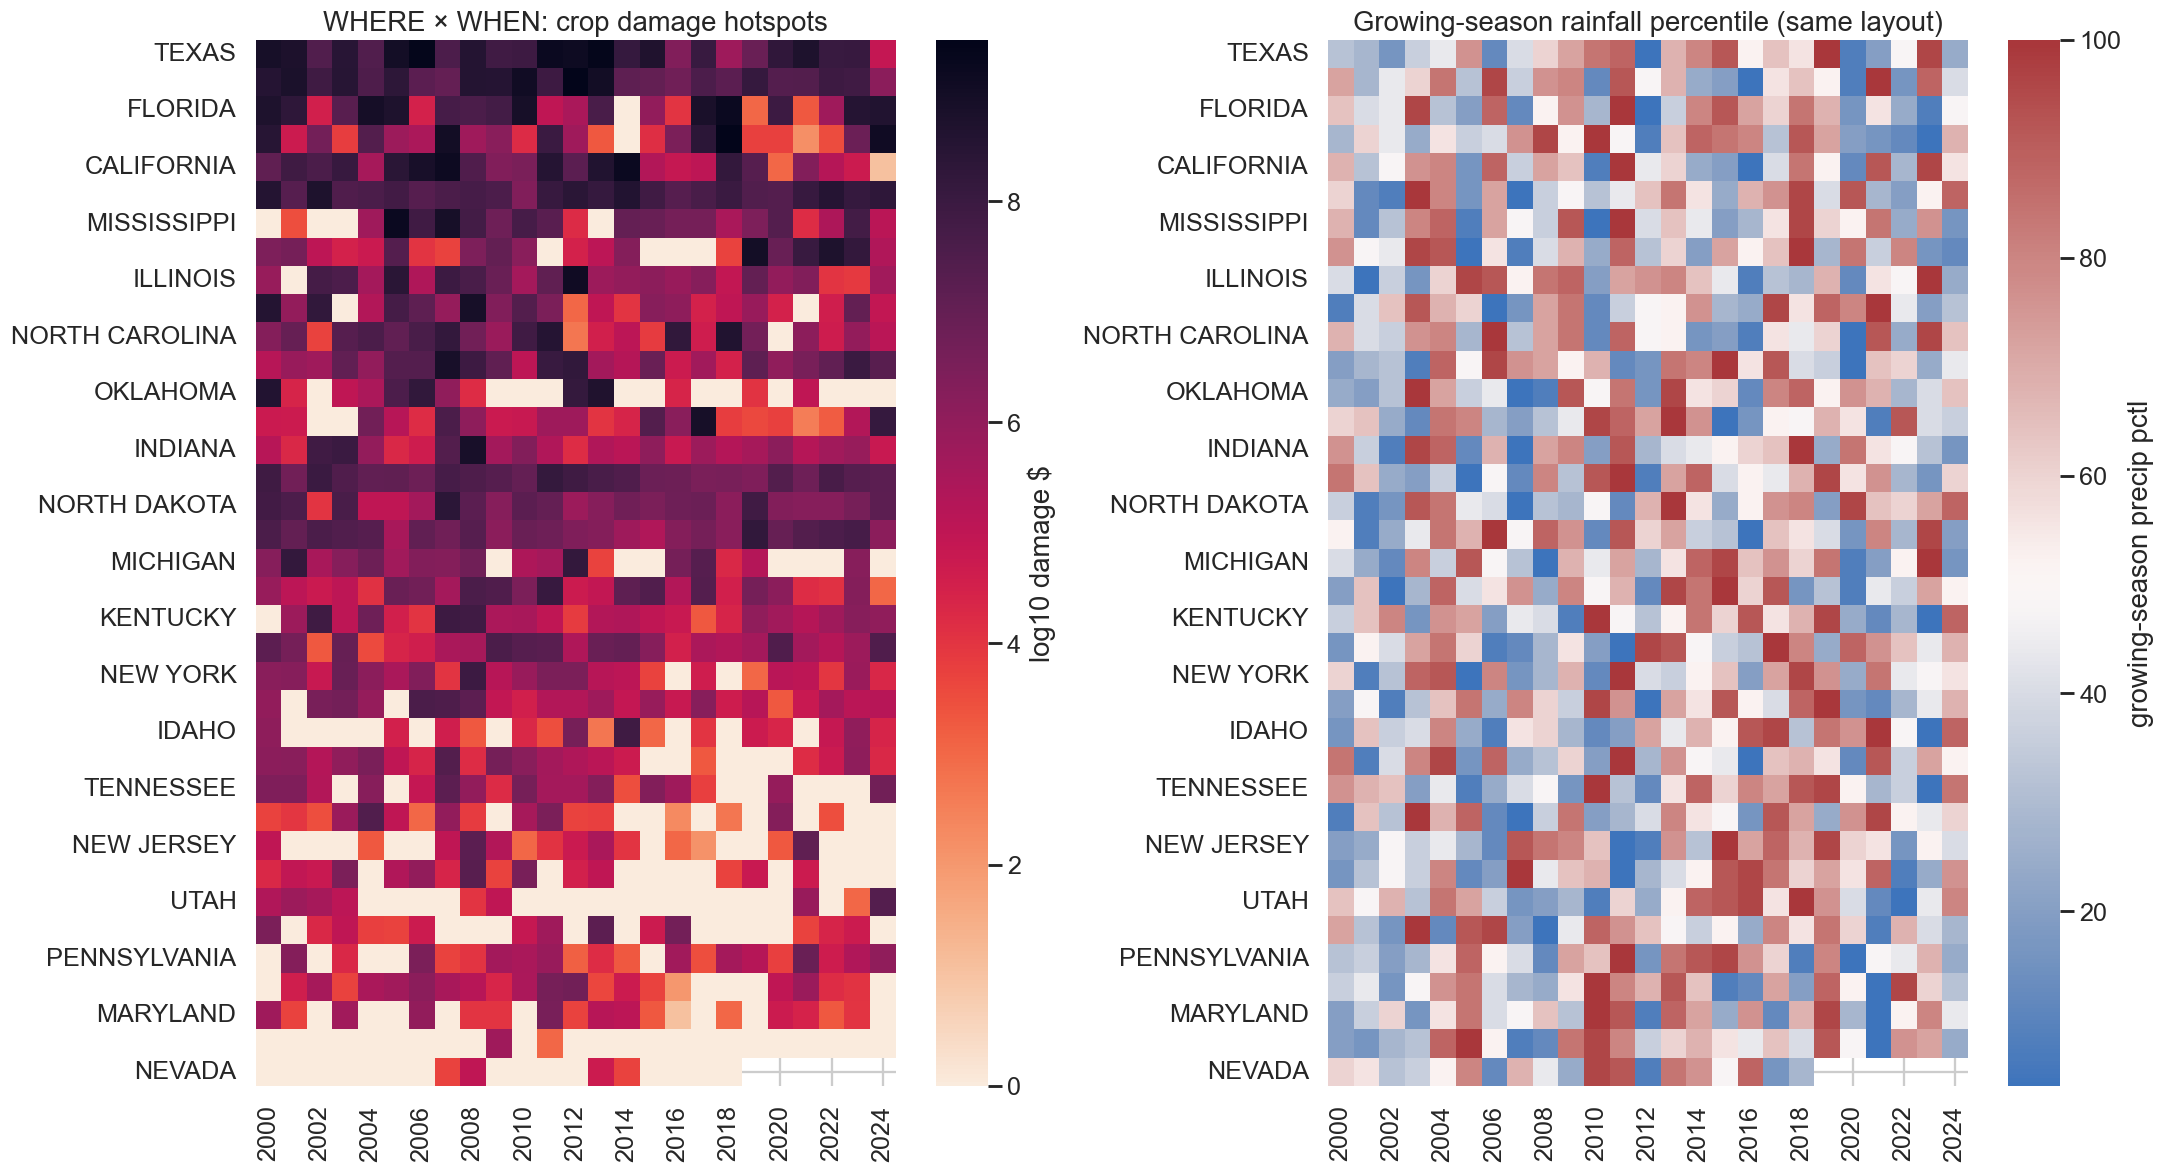

In [12]:
# WHERE x WHEN — the hotspot map, and why rainfall percentile can't predict it.
order = agg.index.tolist()
dmg = (sy.pivot_table(index="state", columns="year",
                      values="crop_damage_usd").reindex(order))
pct = sy.pivot_table(index="state", columns="year",
                     values="growing_season_precip_state_percentile"
                     ).reindex(order)

fig, ax = plt.subplots(1, 2, figsize=(20, 11))
sns.heatmap(np.log10(dmg + 1), cmap="rocket_r", ax=ax[0],
            cbar_kws=dict(label="log10 damage $"))
ax[0].set_title("WHERE × WHEN: crop damage hotspots")
sns.heatmap(pct, cmap="vlag", center=50, ax=ax[1],
            cbar_kws=dict(label="growing-season precip pctl"))
ax[1].set_title("Growing-season rainfall percentile (same layout)")
for a in ax:
    a.set_xlabel(""); a.set_ylabel("")
plt.tight_layout(); plt.show()

The two grids **do not match**. Bright damage cells sit on top of perfectly
ordinary rainfall percentiles. The catastrophes confirm it — they span the
entire wet↔dry spectrum:

In [13]:
top_events = (sy.sort_values("crop_damage_usd", ascending=False)
                .head(12)
                .assign(rain_year=lambda d: np.select(
                    [d["growing_season_precip_state_percentile"] <= 33,
                     d["growing_season_precip_state_percentile"] >= 67],
                    ["DRY", "WET"], "NORMAL")))
top_events[["year", "state_abbr", "annual_precip_in",
            "growing_season_precip_state_percentile", "rain_year",
            "crop_damage_event_count", "crop_damage_usd"]]

,year,state_abbr,annual_precip_in,growing_season_precip_state_percentile,rain_year,crop_damage_event_count,crop_damage_usd
223,2018,GA,44.951,92.000,WET,26.000,"2,888,001,400.000"
443,2012,IA,41.597,48.000,NORMAL,240.000,"2,774,948,000.000"
682,2006,TX,12.936,12.000,DRY,139.000,"2,429,977,400.000"
430,2013,TX,16.791,68.000,WET,587.000,"2,247,948,100.000"
502,2011,TX,18.853,88.000,WET,494.000,"1,579,658,000.000"
702,2005,MS,48.990,8.000,DRY,211.000,"1,522,690,000.000"
363,2014,CA,44.586,24.000,DRY,6.000,"1,501,245,700.000"
222,2018,FL,50.527,84.000,WET,10.000,"1,500,000,000.000"
615,2007,CA,45.201,36.000,NORMAL,49.000,"1,356,017,000.000"
466,2012,TX,10.823,4.000,DRY,252.000,"1,282,127,500.000"


C:\Users\chenr\AppData\Local\Temp\ipykernel_364\2062125565.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(detrend))


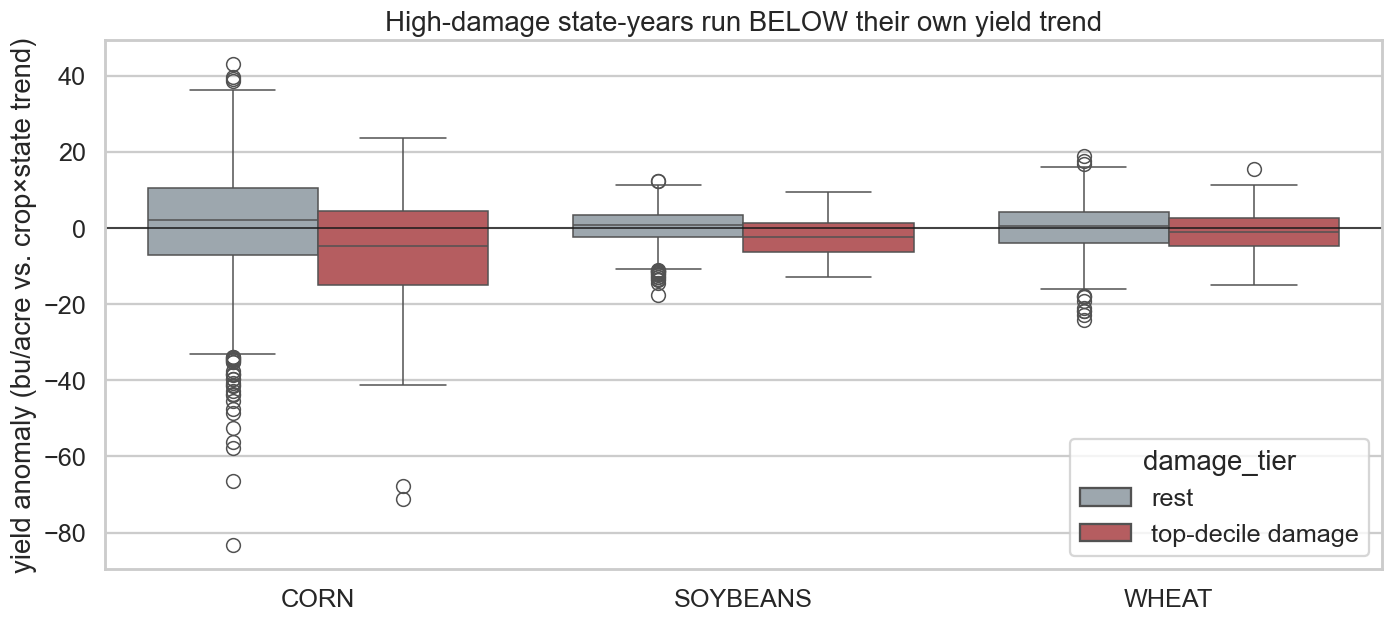

In [14]:
# Detrend yield within crop x state (remove the technology trend), then ask:
# do high-damage years still depress yield even when rainfall looks normal?
def detrend(g):
    if g["yield_bu_per_acre"].notna().sum() < 6:
        return pd.Series(np.nan, index=g.index)
    b = np.polyfit(g["year"], g["yield_bu_per_acre"], 1)
    return g["yield_bu_per_acre"] - np.polyval(b, g["year"])

df["yield_anom"] = (df.groupby(["crop", "state"], group_keys=False)
                      .apply(detrend))
dmg_q = df["crop_damage_usd"].quantile(.90)
df["damage_tier"] = np.where(df["crop_damage_usd"] >= dmg_q,
                             "top-decile damage", "rest")

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df, x="crop", y="yield_anom", hue="damage_tier",
            order=["CORN", "SOYBEANS", "WHEAT"],
            palette={"top-decile damage": "#c44e52", "rest": "#9aa7b1"},
            ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_title("High-damage state-years run BELOW their own yield trend")
ax.set_ylabel("yield anomaly (bu/acre vs. crop×state trend)")
ax.set_xlabel("")
plt.tight_layout(); plt.show()

先在每个 crop × state 内部去掉长期 yield trend，得到 yield_anom；然后把 damage 最高的 10% records 标成 top-decile damage；最后比较这些高损失 records 的 yield anomaly 是否比普通 records 更低

高 crop damage 的 state-year，产量通常会低于该州该作物自己的长期趋势。

In [15]:
# Quantify the blind spot: of the worst-damage state-years, how many would a
# rainfall-percentile screen have flagged at all?
worst = sy[sy["crop_damage_usd"] >= sy["crop_damage_usd"].quantile(.90)]
normal_rain = worst["growing_season_precip_state_percentile"].between(25, 75)
print(f"Top-decile damage state-years: {len(worst)}")
print(f"  ...with 'normal' growing-season rain (25-75th pctl): "
      f"{normal_rain.mean():.0%}")
print(f"  ...median damage in those 'normal-rain' years: "
      f"${worst.loc[normal_rain, 'crop_damage_usd'].median():,.0f}")
print("\nA rainfall-percentile filter would have ignored most of the "
      "costliest crop-damage years entirely.")

Top-decile damage state-years: 92
  ...with 'normal' growing-season rain (25-75th pctl): 50%
  ...median damage in those 'normal-rain' years: $339,097,550

A rainfall-percentile filter would have ignored most of the costliest crop-damage years entirely.


## 4 · So what this sets up

- **AND** — yields are crop-specific and trend up with technology; rainfall
  arrives in very different *forms* (in- vs. off-season) even at equal totals.
- **BUT** — annual rainfall total **and** its percentile are ~0-correlated with
  both yield and crop damage; damage is rare and the top 5% of state-years carry
  the overwhelming majority of all losses.
- **THEREFORE** — damage is concentrated in specific **state × year** cells that
  do **not** align with rainfall extremes and span dry, normal, and wet years
  alike; high-damage years sit measurably below their own yield trend.

**Next steps for the project:** move from totals to *event-aware* signals —
build state-year stress indicators (drought/excess/freeze/wind flags from the
event records), and model yield anomaly against those rather than annual rainfall.